# SEA-AD Dataset — Basic Analysis for Presentation
This notebook explores the **SEA-AD** dataset combining two single-nucleus modalities:
- **snATAC-seq** (chromatin accessibility)
- **snRNA-seq** (gene expression)

across **82 donors** (84 total minus 2 reference donors).

> ⚠️ **RAM-efficient approach**: We load only `.obs` metadata using `backed` mode or `h5py` — no full count matrices are loaded into memory unless strictly necessary.

## 1. Import Required Libraries

In [1]:
# Lightweight imports only — no scanpy/anndata full load yet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Metadata Only (No Full Matrix)

We use `h5py` to read only the `.obs` slot from each `.h5ad` file, avoiding loading the full count matrix into RAM.

In [ ]:
import h5py
import os

# ── Adjust these paths to your actual .h5ad files ──────────────────────────
ATAC_H5AD = "../data/raw/SEAAD_MTG_ATACseq_all-nuclei.2024-12-06.h5ad"
RNA_H5AD  = "../data/raw/SEAAD_MTG_RNAseq_all-nuclei.2024-02-13.h5ad"
# ───────────────────────────────────────────────────────────────────────────

def load_obs_from_h5ad(filepath: str) -> pd.DataFrame:
    """
    Read only the .obs DataFrame from an AnnData .h5ad file using h5py.
    This avoids loading the full count matrix into RAM.
    """
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"File not found: {filepath}")

    with h5py.File(filepath, "r") as f:
        obs_group = f["obs"]

        # Collect columns
        data = {}
        # The index is usually stored under '_index' or 'index'
        index_key = obs_group.attrs.get("_index", "_index")
        index_vals = obs_group[index_key][()].astype(str)

        for key in obs_group.keys():
            if key == index_key:
                continue
            item = obs_group[key]
            # Categorical columns are stored as groups with 'codes' and 'categories'
            if isinstance(item, h5py.Group) and "codes" in item and "categories" in item:
                codes      = item["codes"][()]
                categories = item["categories"][()].astype(str)
                arr = pd.Categorical.from_codes(codes, categories=categories)
                data[key] = arr
            elif isinstance(item, h5py.Dataset):
                raw = item[()]
                if raw.dtype.kind in ("S", "O"):   # byte strings
                    raw = raw.astype(str)
                data[key] = raw

    df = pd.DataFrame(data, index=index_vals)
    df.index.name = "cell_id"
    return df


print("Loading snATAC-seq .obs …")
obs_atac = load_obs_from_h5ad(ATAC_H5AD)
print(f"  → {obs_atac.shape[0]:,} cells × {obs_atac.shape[1]} metadata columns")

print("Loading snRNA-seq .obs …")
obs_rna = load_obs_from_h5ad(RNA_H5AD)
print(f"  → {obs_rna.shape[0]:,} cells × {obs_rna.shape[1]} metadata columns")

Loading snATAC-seq .obs …
  → 1,123,761 cells × 126 metadata columns
Loading snRNA-seq .obs …
  → 1,957,283 cells × 132 metadata columns


In [6]:
# ── DIAGNOSTIC — Lancer en PREMIER avant tout le reste ────────────────────
import h5py, os

ATAC_H5AD = "../data/raw/SEAAD_MTG_ATACseq_all-nuclei.2024-12-06.h5ad"
RNA_H5AD  = "../data/raw/SEAAD_MTG_RNAseq_all-nuclei.2024-02-13.h5ad"

def inspect_obs_keys(filepath, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    with h5py.File(filepath, "r") as f:
        obs = f["obs"]
        print(f"  Index key : {obs.attrs.get('_index', '_index')}")
        print(f"  Columns ({len(obs.keys())}) :")
        for key in sorted(obs.keys()):
            item = obs[key]
            if isinstance(item, h5py.Group):
                cats = item["categories"][()].astype(str)[:5]
                print(f"    [CAT]  {key:40s} → ex: {list(cats)}")
            else:
                sample = item[()]
                if sample.dtype.kind in ("S", "O"):
                    sample = sample.astype(str)
                print(f"    [NUM]  {key:40s} → dtype={item.dtype}, ex={sample.flat[:3].tolist()}")

inspect_obs_keys(ATAC_H5AD, "snATAC-seq")
inspect_obs_keys(RNA_H5AD,  "snRNA-seq")


  snATAC-seq
  Index key : index
  Columns (130) :
    [CAT]  APOE Genotype                            → ex: ['2/2', '2/3', '2/4', '3/3', '3/4']
    [NUM]  ATAC_Confidently_mapped_read_pairs       → dtype=float64, ex=[0.9203, 0.9147, 0.9072]
    [NUM]  ATAC_Fraction_of_genome_in_peaks         → dtype=float64, ex=[0.0513, 0.0524, 0.047]
    [NUM]  ATAC_Fraction_of_high_quality_fragments_in_cells → dtype=float64, ex=[0.8883, 0.9107, 0.7335]
    [NUM]  ATAC_Fraction_of_high_quality_fragments_overlapping_TSS → dtype=float64, ex=[0.2016, 0.249, 0.2294]
    [NUM]  ATAC_Fraction_of_high_quality_fragments_overlapping_peaks → dtype=float64, ex=[0.3372, 0.4019, 0.3624]
    [NUM]  ATAC_Fraction_of_transposition_events_in_peaks_in_cells → dtype=float64, ex=[0.3054, 0.3749, 0.3336]
    [NUM]  ATAC_Mean_raw_read_pairs_per_cell        → dtype=float64, ex=[151939.0346, 85402.9495, 36146.1068]
    [NUM]  ATAC_Median_high_quality_fragments_per_cell → dtype=float64, ex=[82706.5, 30223.0, 12741.0]
    [N

KeyError: "Unable to synchronously open object (object 'categories' doesn't exist)"

In [10]:
# ── Adapt the column names below to match your actual .obs fields ──────────
DONOR_COL   = "Donor ID"          # unique donor identifier
AGE_COL     = "Age at Death"      # continuous or binned age
SEX_COL     = "Gender"               # 'Female' / 'Male'
PMI_COL     = "PMI"               # post-mortem interval (hours)
DIAG_COL    = "Cognitive Status"  # or 'diagnosis', 'AD_stage', etc.
PPS_COL     = "Continuous Pseudo-progression Score"               # pseudo-progression / continuous score
RACE_COL    = "race"
# ───────────────────────────────────────────────────────────────────────────

# Reference donors to EXCLUDE (adapt as needed)
REFERENCE_DONORS = []   # e.g. ["donor_ref_1", "donor_ref_2"]

def build_donor_meta(obs: pd.DataFrame, modality: str) -> pd.DataFrame:
    """Collapse cell-level obs to one row per donor."""
    keep_cols = [c for c in [AGE_COL, SEX_COL, PMI_COL, DIAG_COL,
                              PPS_COL, RACE_COL] if c in obs.columns]
    donor_df = (
        obs[[DONOR_COL] + keep_cols]
        .drop_duplicates(subset=DONOR_COL)
        .set_index(DONOR_COL)
    )
    # Remove reference donors
    donor_df = donor_df[~donor_df.index.isin(REFERENCE_DONORS)]
    donor_df["modality"] = modality
    return donor_df

donor_atac = build_donor_meta(obs_atac, "snATAC-seq")
donor_rna  = build_donor_meta(obs_rna,  "snRNA-seq")

print(f"snATAC-seq donors after filtering: {len(donor_atac)}")
print(f"snRNA-seq  donors after filtering: {len(donor_rna)}")

# Shared donor-level metadata (union, then verify consistency)
donor_meta = pd.concat([donor_atac, donor_rna]).drop_duplicates()
print(f"\nCombined donor rows (may include duplicates across modalities): {len(donor_meta)}")
donor_meta.head()

snATAC-seq donors after filtering: 86
snRNA-seq  donors after filtering: 89

Combined donor rows (may include duplicates across modalities): 171


,Age at Death,Gender,PMI,Cognitive Status,Continuous Pseudo-progression Score,modality
Donor ID,,,,,,
H21.33.025,88.0,Female,8.6,No dementia,0.518005,snATAC-seq
H20.33.025,94.0,Male,4.5,No dementia,0.588882,snATAC-seq
H21.33.003,78.0,Male,10.0,No dementia,0.238033,snATAC-seq
H21.33.008,91.0,Female,5.0,Dementia,0.790347,snATAC-seq
H21.33.038,84.0,Female,11.0,No dementia,0.182370,snATAC-seq


## 3. Age of Death Distribution

/tmp/ipykernel_2026980/119907002.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_df, x="Modality", y="Age",


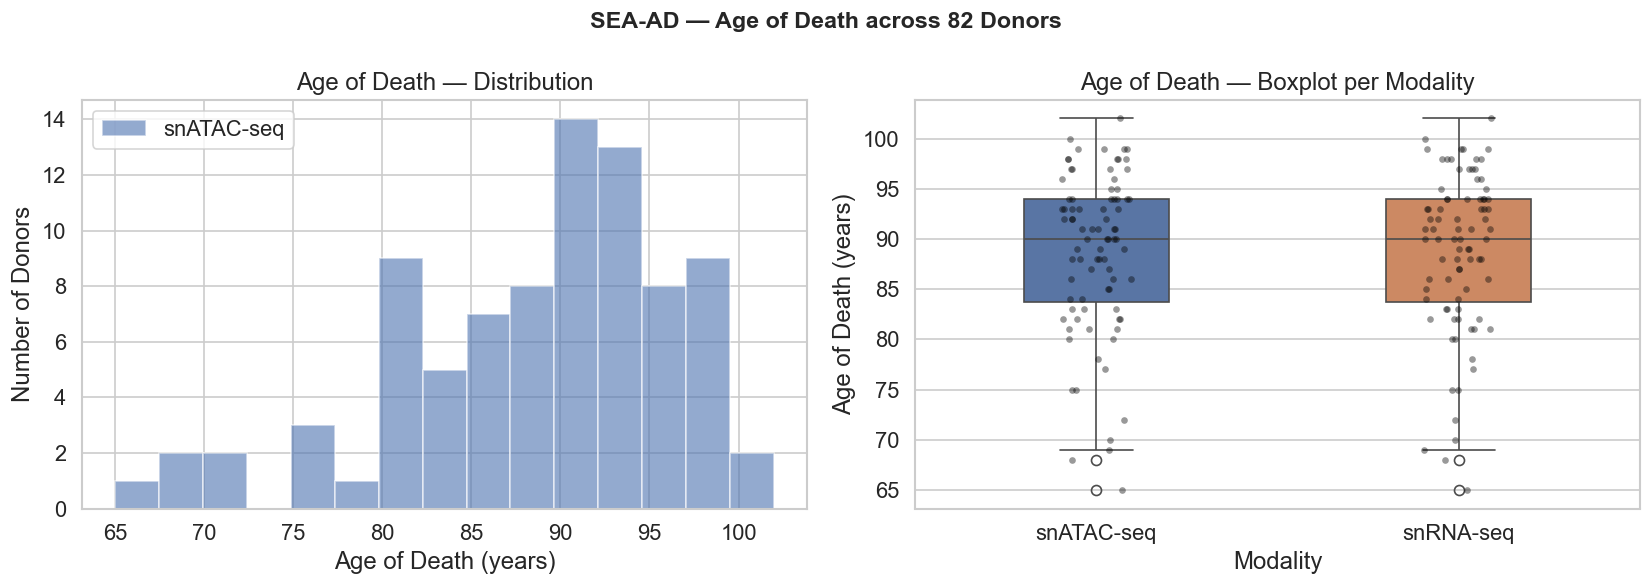


Age stats (snATAC-seq):
count     84.0
mean      88.7
std        8.0
min       65.0
25%       83.8
50%       90.0
75%       94.0
max      102.0
Name: Age at Death, dtype: float64

Age stats (snRNA-seq):
count     84.0
mean      88.7
std        8.0
min       65.0
25%       83.8
50%       90.0
75%       94.0
max      102.0
Name: Age at Death, dtype: float64


In [11]:
if AGE_COL not in donor_atac.columns:
    print(f"⚠️  Column '{AGE_COL}' not found — adapt AGE_COL variable above.")
else:
    # Try to convert to numeric (some datasets store age as "90+" strings)
    def parse_age(series):
        return pd.to_numeric(
            series.astype(str).str.replace("+", "", regex=False), errors="coerce"
        )

    age_atac = parse_age(donor_atac[AGE_COL])
    age_rna  = parse_age(donor_rna[AGE_COL])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # — Histogram —
    ax = axes[0]
    ax.hist(age_atac, bins=15, alpha=0.6, label="snATAC-seq", color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Age of Death (years)")
    ax.set_ylabel("Number of Donors")
    ax.set_title("Age of Death — Distribution")
    ax.legend()

    # — Boxplot —
    ax = axes[1]
    age_df = pd.DataFrame({
        "Age": pd.concat([age_atac, age_rna]),
        "Modality": (["snATAC-seq"] * len(age_atac) + ["snRNA-seq"] * len(age_rna))
    })
    sns.boxplot(data=age_df, x="Modality", y="Age",
                palette=["#4C72B0", "#DD8452"], width=0.4, ax=ax)
    sns.stripplot(data=age_df, x="Modality", y="Age",
                  color="black", alpha=0.4, jitter=True, size=4, ax=ax)
    ax.set_title("Age of Death — Boxplot per Modality")
    ax.set_ylabel("Age of Death (years)")

    plt.suptitle("SEA-AD — Age of Death across 82 Donors", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_age_of_death.png", bbox_inches="tight")
    plt.show()
    print(f"\nAge stats (snATAC-seq):\n{age_atac.describe().round(1)}")
    print(f"\nAge stats (snRNA-seq):\n{age_rna.describe().round(1)}")

## 4. Sex Distribution (Female / Male)

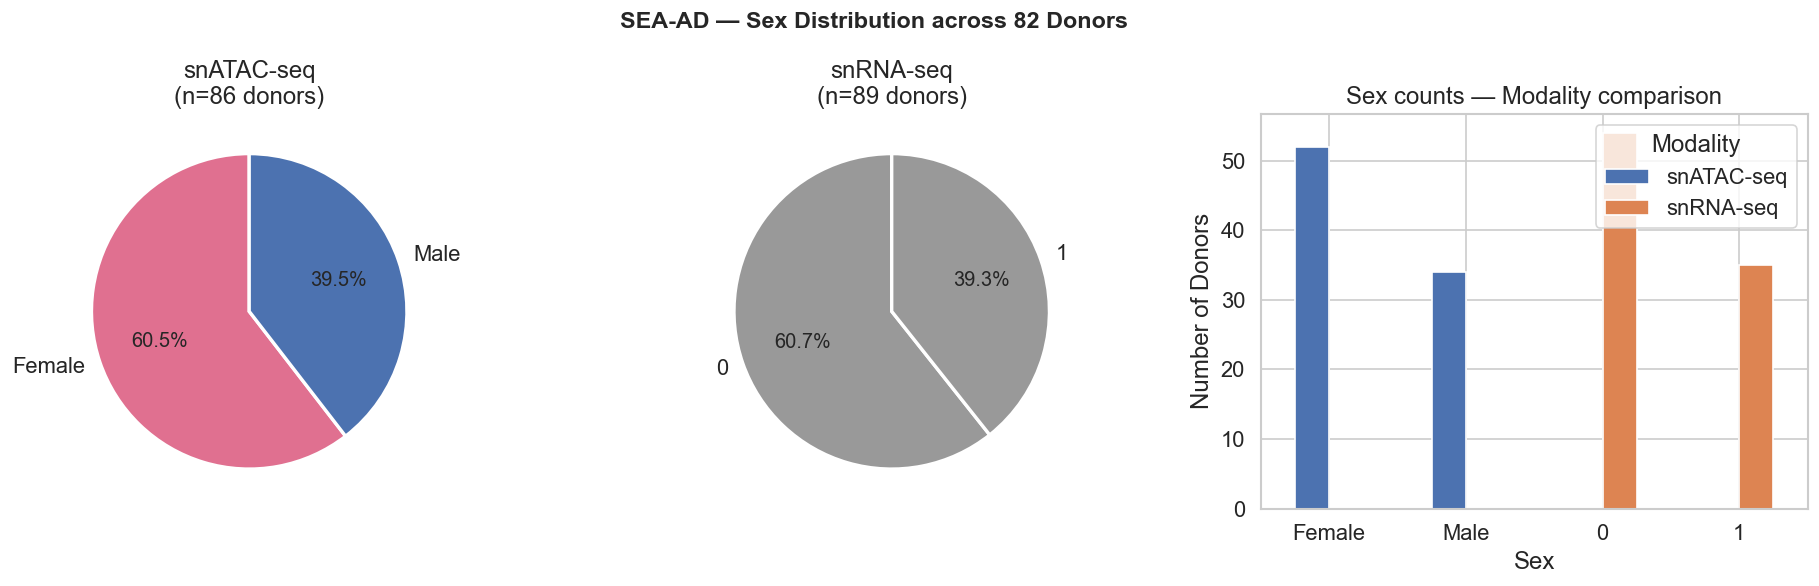

In [12]:
if SEX_COL not in donor_atac.columns:
    print(f"⚠️  Column '{SEX_COL}' not found — adapt SEX_COL variable above.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    palette_sex = {"Female": "#E07090", "Male": "#4C72B0",
                   "F": "#E07090", "M": "#4C72B0"}

    for ax, (df, label) in zip(axes[:2], [(donor_atac, "snATAC-seq"),
                                           (donor_rna,  "snRNA-seq")]):
        counts = df[SEX_COL].value_counts()
        colors = [palette_sex.get(c, "#999999") for c in counts.index]
        wedges, texts, autotexts = ax.pie(
            counts, labels=counts.index, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2)
        )
        for at in autotexts:
            at.set_fontsize(12)
        ax.set_title(f"{label}\n(n={counts.sum()} donors)")

    # — Grouped bar comparing both modalities —
    ax = axes[2]
    sex_summary = pd.DataFrame({
        "snATAC-seq": donor_atac[SEX_COL].value_counts(),
        "snRNA-seq" : donor_rna[SEX_COL].value_counts()
    }).fillna(0).astype(int)

    sex_summary.plot(kind="bar", ax=ax,
                     color=["#4C72B0", "#DD8452"], edgecolor="white",
                     rot=0, width=0.5)
    ax.set_title("Sex counts — Modality comparison")
    ax.set_xlabel("Sex")
    ax.set_ylabel("Number of Donors")
    ax.legend(title="Modality")

    plt.suptitle("SEA-AD — Sex Distribution across 82 Donors",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_sex_distribution.png", bbox_inches="tight")
    plt.show()

## 5. Donor-level Covariates Overview

In [13]:
# Build a clean donor-level summary for one modality (use snRNA-seq as reference)
covariate_cols = [c for c in [AGE_COL, SEX_COL, PMI_COL, DIAG_COL, RACE_COL]
                  if c in donor_rna.columns]

summary_df = donor_rna[covariate_cols].copy()

# Numeric summary table
numeric_cols = summary_df.select_dtypes(include="number").columns.tolist()
print("=== Numeric covariates (snRNA-seq donors) ===")
display(summary_df[numeric_cols].describe().round(2))

# Categorical value counts
cat_cols = summary_df.select_dtypes(exclude="number").columns.tolist()
for col in cat_cols:
    print(f"\n── {col} ──")
    print(summary_df[col].value_counts().to_string())

=== Numeric covariates (snRNA-seq donors) ===


,Age at Death,Gender,PMI,Cognitive Status
count,84.00,89.00,89.00,89.00
mean,88.73,0.39,28.38,1.42
std,8.03,0.49,18.31,0.60
min,65.00,0.00,0.00,0.00
25%,83.75,0.00,13.00,1.00
50%,90.00,0.00,26.00,1.00
75%,94.00,1.00,45.00,2.00
max,102.00,1.00,60.00,2.00


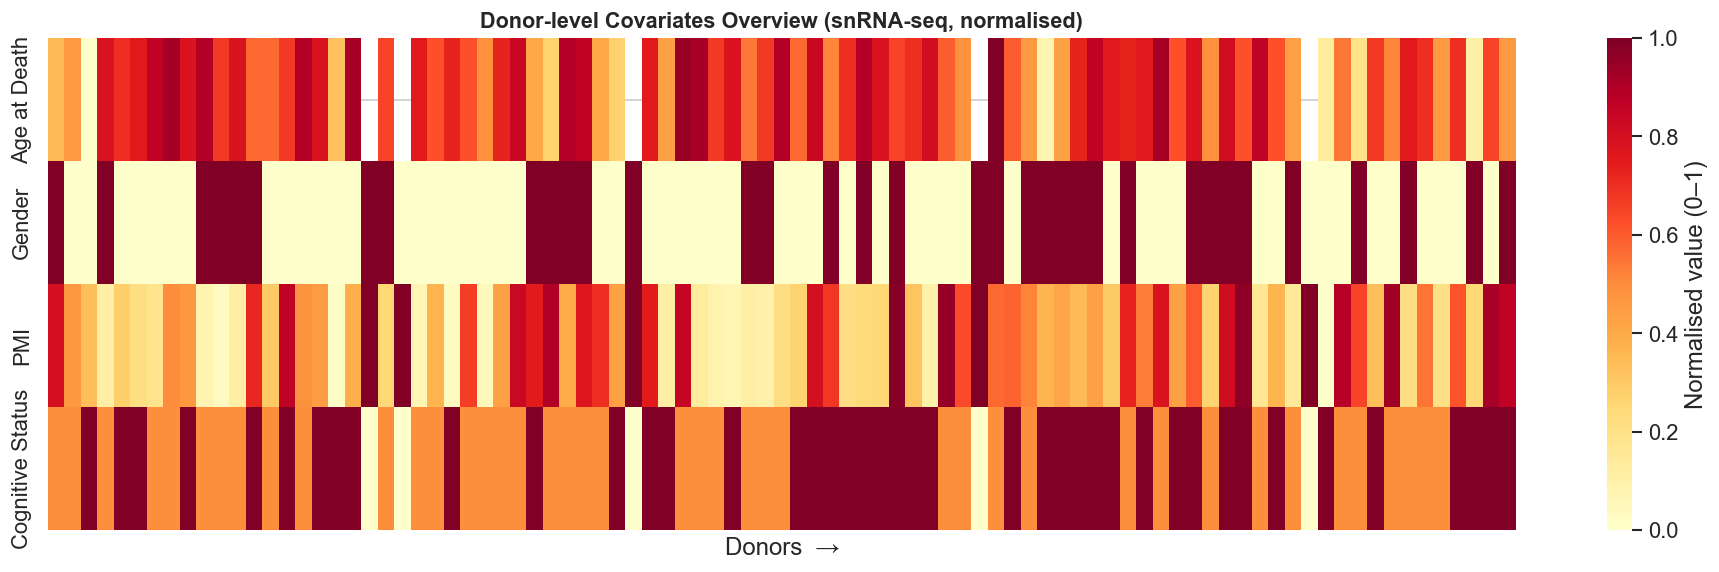

In [14]:
# Heatmap: encode categorical columns numerically for visualisation
heatmap_df = summary_df.copy()

for col in cat_cols:
    heatmap_df[col] = pd.Categorical(heatmap_df[col]).codes.astype(float)

# Normalise each column 0–1
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min() + 1e-9)
heatmap_norm = heatmap_norm.T  # donors as columns, covariates as rows

fig, ax = plt.subplots(figsize=(max(14, len(heatmap_norm.columns) * 0.18), 5))
sns.heatmap(
    heatmap_norm, ax=ax,
    cmap="YlOrRd", linewidths=0,
    xticklabels=False,                    # too many donors to label
    yticklabels=heatmap_norm.index,
    cbar_kws={"label": "Normalised value (0–1)"}
)
ax.set_xlabel("Donors  →")
ax.set_title("Donor-level Covariates Overview (snRNA-seq, normalised)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_covariate_heatmap.png", bbox_inches="tight")
plt.show()

## 6. PPS and Disease-related Covariates

/tmp/ipykernel_2026980/295428765.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diag_pps, x=DIAG_COL, y=PPS_COL, order=order,
/tmp/ipykernel_2026980/295428765.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


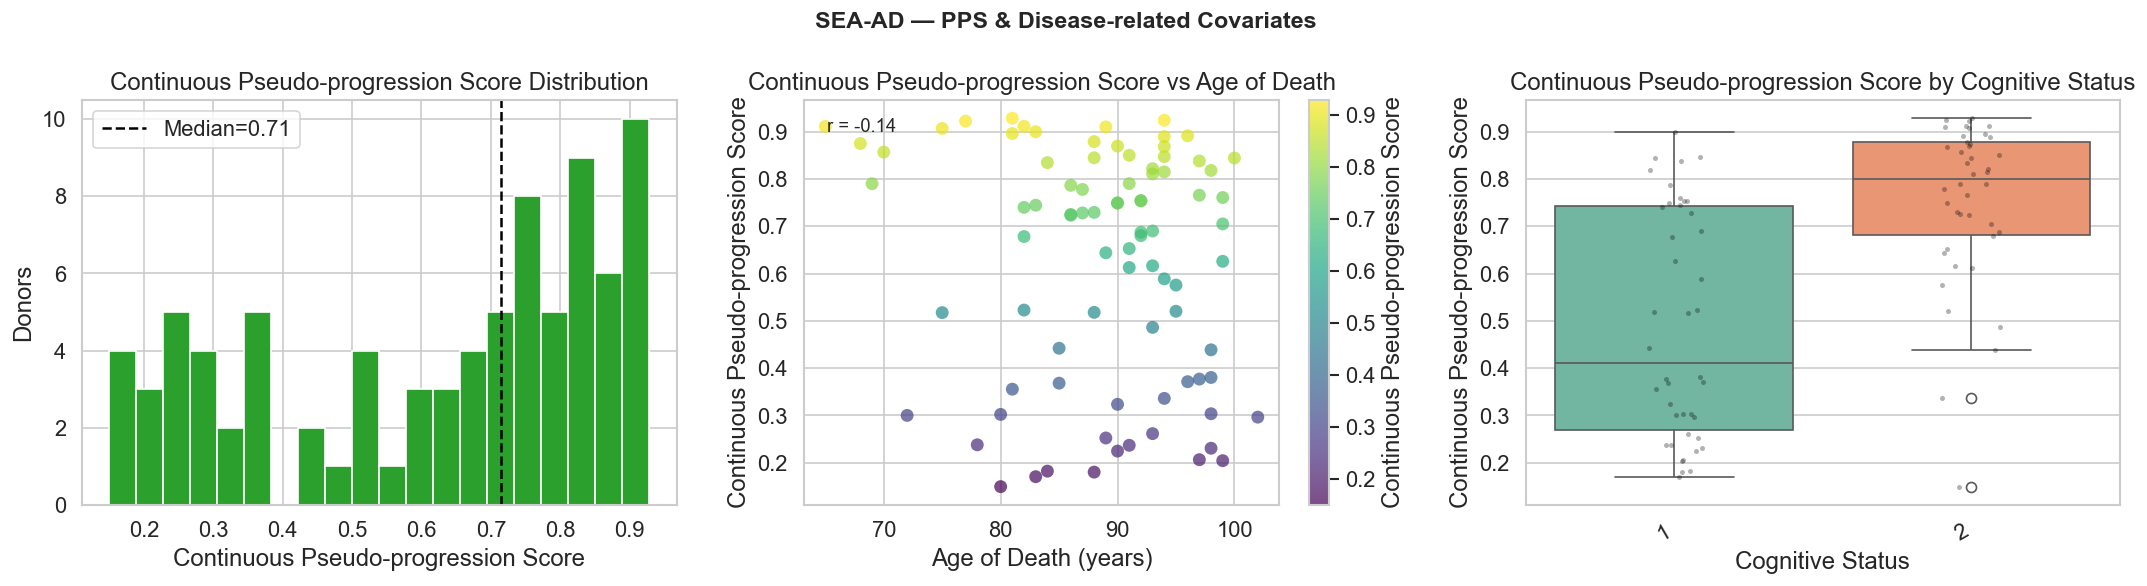

In [15]:
if PPS_COL not in donor_rna.columns:
    print(f"⚠️  Column '{PPS_COL}' not found — adapt PPS_COL variable above.")
else:
    pps = pd.to_numeric(donor_rna[PPS_COL], errors="coerce")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # — PPS distribution —
    ax = axes[0]
    ax.hist(pps.dropna(), bins=20, color="#2ca02c", edgecolor="white")
    ax.axvline(pps.median(), color="black", linestyle="--", label=f"Median={pps.median():.2f}")
    ax.set_xlabel(PPS_COL)
    ax.set_ylabel("Donors")
    ax.set_title(f"{PPS_COL} Distribution")
    ax.legend()

    # — PPS vs Age of Death —
    if AGE_COL in donor_rna.columns:
        age = pd.to_numeric(
            donor_rna[AGE_COL].astype(str).str.replace("+", "", regex=False),
            errors="coerce"
        )
        ax = axes[1]
        sc = ax.scatter(age, pps, alpha=0.7, c=pps, cmap="viridis", edgecolors="none", s=60)
        plt.colorbar(sc, ax=ax, label=PPS_COL)
        ax.set_xlabel("Age of Death (years)")
        ax.set_ylabel(PPS_COL)
        ax.set_title(f"{PPS_COL} vs Age of Death")
        # Pearson correlation
        mask = age.notna() & pps.notna()
        r = np.corrcoef(age[mask], pps[mask])[0, 1]
        ax.annotate(f"r = {r:.2f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=11)

    # — PPS by diagnosis / cognitive status —
    if DIAG_COL in donor_rna.columns:
        ax = axes[2]
        diag_pps = pd.DataFrame({DIAG_COL: donor_rna[DIAG_COL], PPS_COL: pps}).dropna()
        order = diag_pps.groupby(DIAG_COL)[PPS_COL].median().sort_values().index.tolist()
        sns.boxplot(data=diag_pps, x=DIAG_COL, y=PPS_COL, order=order,
                    palette="Set2", ax=ax)
        sns.stripplot(data=diag_pps, x=DIAG_COL, y=PPS_COL, order=order,
                      color="black", alpha=0.3, jitter=True, size=3, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
        ax.set_title(f"{PPS_COL} by {DIAG_COL}")

    plt.suptitle("SEA-AD — PPS & Disease-related Covariates",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_pps_covariates.png", bbox_inches="tight")
    plt.show()

## 7. snATAC-seq QC Metrics per Donor

We work directly with the cell-level `obs_atac` DataFrame already loaded in memory — no extra file read needed.

In [16]:
# ── Adapt column names to your snATAC-seq .obs fields ─────────────────────
ATAC_FRAGS_COL = "num_fragments"       # total fragments per cell
ATAC_TSS_COL   = "tss_enrichment"     # TSS enrichment score
# ───────────────────────────────────────────────────────────────────────────

available_qc = [c for c in [ATAC_FRAGS_COL, ATAC_TSS_COL] if c in obs_atac.columns]

if not available_qc:
    print("⚠️  None of the expected QC columns found in snATAC-seq .obs.")
    print("Available columns:", obs_atac.columns.tolist())
else:
    # Cells per donor
    cells_per_donor_atac = (
        obs_atac[~obs_atac[DONOR_COL].isin(REFERENCE_DONORS)]
        .groupby(DONOR_COL)
        .size()
        .reset_index(name="n_cells")
        .sort_values("n_cells", ascending=False)
    )

    n_metrics = len(available_qc)
    fig, axes = plt.subplots(1, n_metrics + 1, figsize=(6 * (n_metrics + 1), 5))
    if n_metrics + 1 == 1:
        axes = [axes]

    # — Cells per donor barplot —
    ax = axes[0]
    ax.bar(range(len(cells_per_donor_atac)), cells_per_donor_atac["n_cells"],
           color="#4C72B0", edgecolor="none", width=1.0)
    ax.set_xlabel("Donors (ranked by cell count)")
    ax.set_ylabel("Number of Cells")
    ax.set_title("snATAC-seq — Cells per Donor")
    ax.axhline(cells_per_donor_atac["n_cells"].median(), color="red",
               linestyle="--", label=f'Median={cells_per_donor_atac["n_cells"].median():.0f}')
    ax.legend()

    # — QC metric distributions per donor (violin) —
    obs_atac_filt = obs_atac[~obs_atac[DONOR_COL].isin(REFERENCE_DONORS)].copy()
    for ax, qc_col in zip(axes[1:], available_qc):
        # Subsample for plotting speed (max 50k cells)
        plot_df = obs_atac_filt[[DONOR_COL, qc_col]].dropna()
        if len(plot_df) > 50_000:
            plot_df = plot_df.sample(50_000, random_state=42)
        sns.violinplot(data=plot_df, x=DONOR_COL, y=qc_col,
                       inner="quartile", color="#4C72B0", ax=ax,
                       scale="width", linewidth=0.8)
        ax.set_xticklabels([])
        ax.set_xlabel("Donors")
        ax.set_title(f"snATAC-seq — {qc_col}")

    plt.suptitle("SEA-AD — snATAC-seq QC Metrics per Donor",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_atac_qc.png", bbox_inches="tight")
    plt.show()

⚠️  None of the expected QC columns found in snATAC-seq .obs.
Available columns: ['APOE Genotype', 'ATAC_Confidently_mapped_read_pairs', 'ATAC_Fraction_of_genome_in_peaks', 'ATAC_Fraction_of_high_quality_fragments_in_cells', 'ATAC_Fraction_of_high_quality_fragments_overlapping_TSS', 'ATAC_Fraction_of_high_quality_fragments_overlapping_peaks', 'ATAC_Fraction_of_transposition_events_in_peaks_in_cells', 'ATAC_Mean_raw_read_pairs_per_cell', 'ATAC_Median_high_quality_fragments_per_cell', 'ATAC_Non-nuclear_read_pairs', 'ATAC_Number_of_peaks', 'ATAC_Percent_duplicates', 'ATAC_Q30_bases_in_barcode', 'ATAC_Q30_bases_in_read_1', 'ATAC_Q30_bases_in_read_2', 'ATAC_Q30_bases_in_sample_index_i1', 'ATAC_Sequenced_read_pairs', 'ATAC_TSS_enrichment_score', 'ATAC_Unmapped_read_pairs', 'ATAC_Valid_barcodes', 'Age at Death', 'Arteriolosclerosis', 'Atherosclerosis', 'Braak', 'Brain Region', 'Brain pH', 'CERAD score', 'Class', 'Class confidence', 'Cognitive Status', 'Continuous Pseudo-progression Score', 'D

## 8. snRNA-seq QC Metrics per Donor

In [ ]:
# ── Adapt column names to your snRNA-seq .obs fields ──────────────────────
RNA_NGENES_COL = "n_genes_by_counts"   # number of genes detected
RNA_COUNTS_COL = "total_counts"        # total UMI counts
# ───────────────────────────────────────────────────────────────────────────

available_qc_rna = [c for c in [RNA_NGENES_COL, RNA_COUNTS_COL] if c in obs_rna.columns]

if not available_qc_rna:
    print("⚠️  None of the expected QC columns found in snRNA-seq .obs.")
    print("Available columns:", obs_rna.columns.tolist())
else:
    cells_per_donor_rna = (
        obs_rna[~obs_rna[DONOR_COL].isin(REFERENCE_DONORS)]
        .groupby(DONOR_COL)
        .size()
        .reset_index(name="n_cells")
        .sort_values("n_cells", ascending=False)
    )

    n_metrics_rna = len(available_qc_rna)
    fig, axes = plt.subplots(1, n_metrics_rna + 1, figsize=(6 * (n_metrics_rna + 1), 5))
    if n_metrics_rna + 1 == 1:
        axes = [axes]

    # — Cells per donor —
    ax = axes[0]
    ax.bar(range(len(cells_per_donor_rna)), cells_per_donor_rna["n_cells"],
           color="#DD8452", edgecolor="none", width=1.0)
    ax.set_xlabel("Donors (ranked by cell count)")
    ax.set_ylabel("Number of Cells")
    ax.set_title("snRNA-seq — Cells per Donor")
    ax.axhline(cells_per_donor_rna["n_cells"].median(), color="red",
               linestyle="--", label=f'Median={cells_per_donor_rna["n_cells"].median():.0f}')
    ax.legend()

    # — QC metric distributions —
    obs_rna_filt = obs_rna[~obs_rna[DONOR_COL].isin(REFERENCE_DONORS)].copy()
    for ax, qc_col in zip(axes[1:], available_qc_rna):
        plot_df = obs_rna_filt[[DONOR_COL, qc_col]].dropna()
        if len(plot_df) > 50_000:
            plot_df = plot_df.sample(50_000, random_state=42)
        sns.violinplot(data=plot_df, x=DONOR_COL, y=qc_col,
                       inner="quartile", color="#DD8452", ax=ax,
                       scale="width", linewidth=0.8)
        ax.set_xticklabels([])
        ax.set_xlabel("Donors")
        ax.set_title(f"snRNA-seq — {qc_col}")

    plt.suptitle("SEA-AD — snRNA-seq QC Metrics per Donor",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig_rna_qc.png", bbox_inches="tight")
    plt.show()

## 9. Cross-modality Donor Overlap

In [17]:
donors_atac = set(donor_atac.index.tolist())
donors_rna  = set(donor_rna.index.tolist())

only_atac   = donors_atac - donors_rna
only_rna    = donors_rna  - donors_atac
both        = donors_atac & donors_rna

print(f"Donors in snATAC-seq only : {len(only_atac)}")
print(f"Donors in snRNA-seq only  : {len(only_rna)}")
print(f"Donors in BOTH modalities : {len(both)}")

if only_atac:
    print(f"\n⚠️  snATAC-seq only donors: {sorted(only_atac)}")
if only_rna:
    print(f"\n⚠️  snRNA-seq only donors:  {sorted(only_rna)}")

Donors in snATAC-seq only : 86
Donors in snRNA-seq only  : 89
Donors in BOTH modalities : 0

⚠️  snATAC-seq only donors: ['H19.30.002', 'H19.30.004', 'H19.33.004', 'H20.33.001', 'H20.33.002', 'H20.33.004', 'H20.33.005', 'H20.33.008', 'H20.33.011', 'H20.33.012', 'H20.33.013', 'H20.33.014', 'H20.33.015', 'H20.33.016', 'H20.33.017', 'H20.33.018', 'H20.33.019', 'H20.33.020', 'H20.33.024', 'H20.33.025', 'H20.33.026', 'H20.33.027', 'H20.33.028', 'H20.33.029', 'H20.33.030', 'H20.33.031', 'H20.33.032', 'H20.33.033', 'H20.33.034', 'H20.33.035', 'H20.33.036', 'H20.33.037', 'H20.33.038', 'H20.33.039', 'H20.33.040', 'H20.33.041', 'H20.33.043', 'H20.33.044', 'H20.33.045', 'H20.33.046', 'H21.33.001', 'H21.33.002', 'H21.33.003', 'H21.33.004', 'H21.33.005', 'H21.33.006', 'H21.33.007', 'H21.33.008', 'H21.33.009', 'H21.33.010', 'H21.33.011', 'H21.33.012', 'H21.33.013', 'H21.33.014', 'H21.33.015', 'H21.33.016', 'H21.33.017', 'H21.33.018', 'H21.33.019', 'H21.33.020', 'H21.33.021', 'H21.33.022', 'H21.33.02

TypeError: '<' not supported between instances of 'str' and 'int'

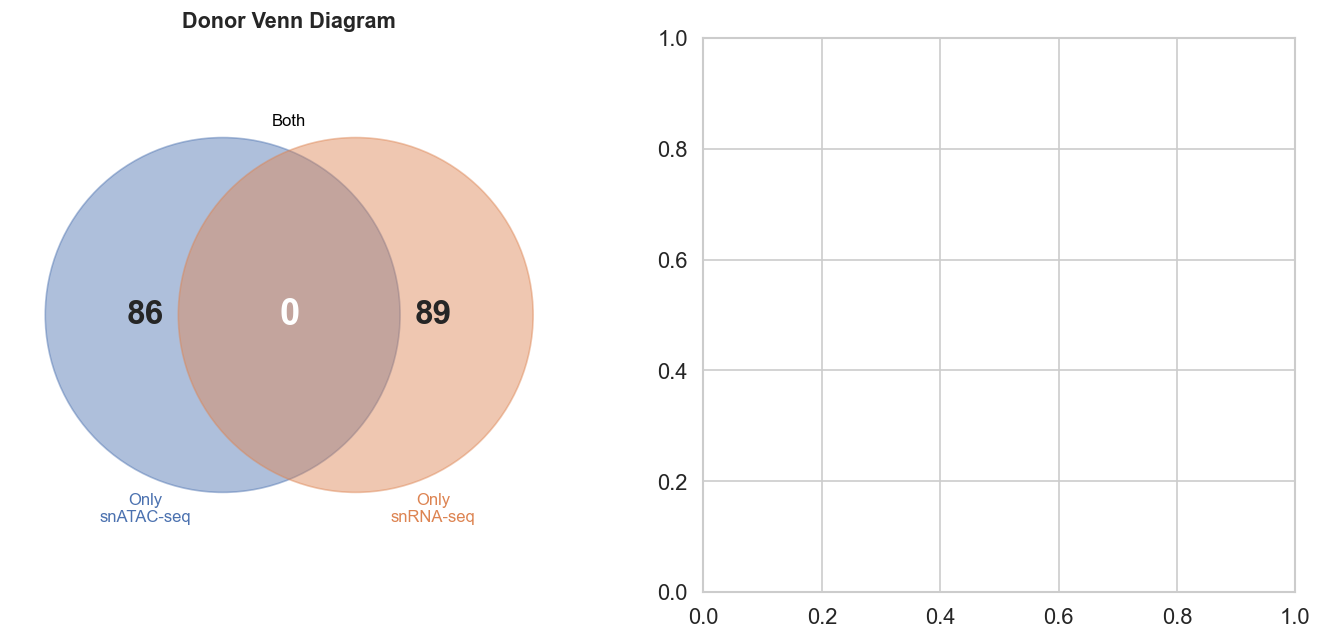

In [18]:
# — Venn-style diagram (manual, no extra lib needed) —
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Venn diagram using matplotlib patches
ax = axes[0]
circle_atac = mpatches.Circle((0.38, 0.5), 0.32, color="#4C72B0", alpha=0.45, label="snATAC-seq")
circle_rna  = mpatches.Circle((0.62, 0.5), 0.32, color="#DD8452", alpha=0.45, label="snRNA-seq")
ax.add_patch(circle_atac)
ax.add_patch(circle_rna)
ax.text(0.24, 0.50, str(len(only_atac)), ha="center", va="center", fontsize=20, fontweight="bold")
ax.text(0.76, 0.50, str(len(only_rna)),  ha="center", va="center", fontsize=20, fontweight="bold")
ax.text(0.50, 0.50, str(len(both)),      ha="center", va="center", fontsize=22, fontweight="bold",
        color="white")
ax.text(0.24, 0.15, "Only\nsnATAC-seq", ha="center", va="center", fontsize=10, color="#4C72B0")
ax.text(0.76, 0.15, "Only\nsnRNA-seq",  ha="center", va="center", fontsize=10, color="#DD8452")
ax.text(0.50, 0.85, "Both", ha="center", va="center", fontsize=10, color="black")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Donor Venn Diagram", fontsize=13, fontweight="bold")

# — Presence / absence heatmap —
ax = axes[1]
all_donors = sorted(donors_atac | donors_rna)
presence = pd.DataFrame({
    "snATAC-seq": [1 if d in donors_atac else 0 for d in all_donors],
    "snRNA-seq":  [1 if d in donors_rna  else 0 for d in all_donors],
}, index=all_donors)

sns.heatmap(
    presence.T, ax=ax,
    cmap=["#f0f0f0", "#2ca02c"],
    linewidths=0.3, linecolor="white",
    xticklabels=False, yticklabels=True,
    cbar=False, vmin=0, vmax=1
)
present_patch = mpatches.Patch(color="#2ca02c", label="Present")
absent_patch  = mpatches.Patch(color="#f0f0f0", label="Absent")
ax.legend(handles=[present_patch, absent_patch], loc="upper right", fontsize=10)
ax.set_xlabel(f"Donors (n={len(all_donors)} total)  →")
ax.set_title("Presence / Absence per Modality", fontsize=13, fontweight="bold")

plt.suptitle("SEA-AD — Cross-modality Donor Overlap",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_donor_overlap.png", bbox_inches="tight")
plt.show()

---
## Summary

| Figure | File saved |
|--------|-----------|
| Age of Death distribution | `fig_age_of_death.png` |
| Sex distribution | `fig_sex_distribution.png` |
| Covariate heatmap | `fig_covariate_heatmap.png` |
| PPS & disease covariates | `fig_pps_covariates.png` |
| snATAC-seq QC metrics | `fig_atac_qc.png` |
| snRNA-seq QC metrics | `fig_rna_qc.png` |
| Cross-modality overlap | `fig_donor_overlap.png` |

> **Next steps**: Cell-type composition analysis, dimensionality reduction (UMAP), and differential accessibility / expression are intentionally deferred to separate notebooks to manage RAM usage.